# Analysis of Variance (ANOVA)

In [24]:
import numpy as np
import pandas as pd 
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

In [25]:
#Make/fake some data
np.random.seed(1663)
n = 1000

salaries = np.random.normal(50000, 10000, n)
majors = ['Engineering', 'Computer Science', 'Sociology', 'Education'] 
school_types = ['Public', 'Private']
ages = np.random.randint(22, 65, n)
genders = ['Male', 'Female']

data = {
    'Major': np.random.choice(majors, size=n),
    'Salary': salaries,
    'School_Type': np.random.choice(school_types, size=n),
    'Age': ages,
    'Gender': np.random.choice(genders, size=n)
}

df = pd.DataFrame(data)
df.head()

,Major,Salary,School_Type,Age,Gender
0,Engineering,56976.869985,Public,63,Female
1,Sociology,65131.253756,Private,57,Female
2,Engineering,48578.992878,Public,37,Male
3,Computer Science,57645.485173,Public,45,Male
4,Sociology,48566.995676,Public,46,Female


/var/folders/zy/x4gc34qd36q0s944s4dk2n640000gn/T/ipykernel_88207/2325690439.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=categories)


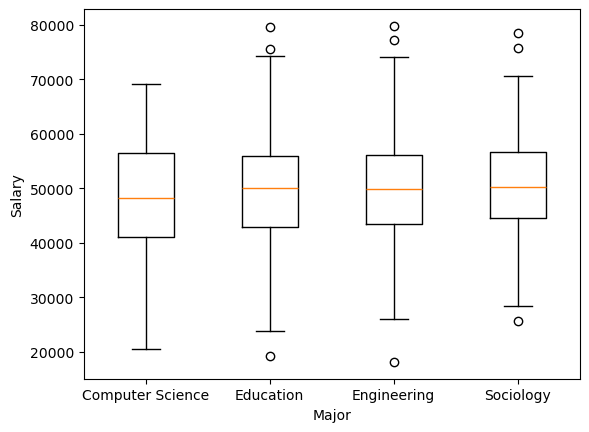

Major
Computer Science    48549.427763
Education           49664.358629
Engineering         50070.233473
Sociology           50372.767963
Name: Salary, dtype: float64


In [26]:
#Box plots by factor (major)
major_grouped_salary = df.groupby('Major')['Salary'].apply(list)
categories = major_grouped_salary.index
values = major_grouped_salary.values
plt.boxplot(values, labels=categories)
plt.xlabel('Major')
plt.ylabel('Salary')
plt.show()

#Means by factor (major)
grouped_means = df.groupby('Major')['Salary'].mean()
print(grouped_means)

In [27]:
#Levene statistical test for homogeneous variance
groups = [group["Salary"].values for _, group in df.groupby("Major")]
levene_test = levene(*groups)
print("Levene statistic:", levene_test.statistic)
print("Levene p-value:", levene_test.pvalue)
#Null hypothesis: Variances are equal.  If p-value is less than cutoff, reject null that variances are equal

Levene statistic: 1.330581121381173
Levene p-value: 0.2630054644425043


In [28]:
#Perform one-way ANOVA with statsmodels
model = ols('Salary ~ C(Major)', data=df).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)
#Null hypothesis: All means are equal

             df        sum_sq       mean_sq         F    PR(>F)
C(Major)    3.0  4.763525e+08  1.587842e+08  1.581945  0.192105
Residual  996.0  9.997128e+10  1.003728e+08       NaN       NaN


In [11]:
#Alternatively, perform one-way ANOVA with scipy's f_oneway function
groups = []
for major, group in df.groupby('Major')['Salary']:
    groups.append(group)

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)
#Null hypothesis: All means are equal
#The associated p-value indicates the probability of observing such an F-statistic under the null hypothesis (no group differences).
#If the p-value is below cutoff, we reject the null hypothesis and conclude that there are significant differences between the groups.

F-statistic: 1.581944768692596
p-value: 0.1921048349775969


/var/folders/zy/x4gc34qd36q0s944s4dk2n640000gn/T/ipykernel_88207/4098612812.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=categories)


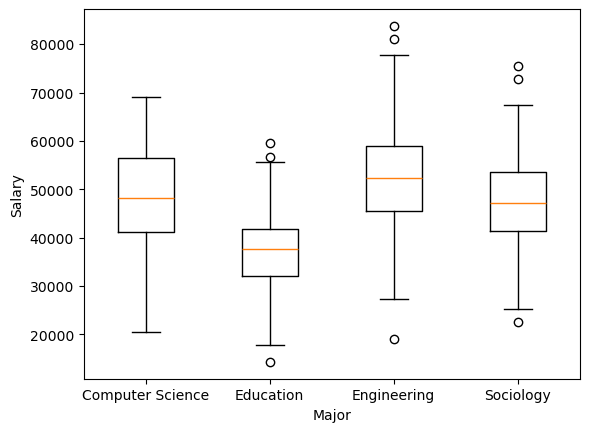

Major
Computer Science    48549.427763
Education           37248.268972
Engineering         52573.745146
Sociology           47372.767963
Name: Salary, dtype: float64


In [12]:
#Create some differences!
df.loc[df['Major'] == 'Engineering', 'Salary'] *= 1.05
df.loc[df['Major'] == 'Education', 'Salary'] *= 0.75
df.loc[df['Major'] == 'Sociology', 'Salary'] -= 3000

major_grouped_salary = df.groupby('Major')['Salary'].apply(list)
categories = major_grouped_salary.index
values = major_grouped_salary.values
plt.boxplot(values, labels=categories)
plt.xlabel('Major')
plt.ylabel('Salary')
plt.show()

grouped_means = df.groupby('Major')['Salary'].mean()
print(grouped_means)

In [30]:
#Perform one-way ANOVA with statsmodels
model = ols('Salary ~ C(Major)', data=df).fit()
anova_table = sm.stats.anova_lm(model)

print(anova_table)

             df        sum_sq       mean_sq         F    PR(>F)
C(Major)    3.0  4.763525e+08  1.587842e+08  1.581945  0.192105
Residual  996.0  9.997128e+10  1.003728e+08       NaN       NaN


In [14]:
#Perform one-way ANOVA with scipy's f_oneway function
groups = []
for major, group in df.groupby('Major')['Salary']:
    groups.append(group)

f_stat, p_value = f_oneway(*groups)

#Print the results
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 118.9029558750706
p-value: 8.064028043020817e-66


In [15]:
#Tukey-Kramer Test for Equal Means Between Groups
model = ols('Salary ~ C(Major)', data=df).fit()
anova_results = sm.stats.anova_lm(model, typ=1)
tukey_results = pairwise_tukeyhsd(endog=df['Salary'], groups=df['Major'], alpha=0.05)
print(tukey_results)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
     group1         group2     meandiff  p-adj     lower      upper    reject
-----------------------------------------------------------------------------
Computer Science   Education -11301.1588    0.0 -13480.2573 -9122.0603   True
Computer Science Engineering   4024.3174    0.0   1866.1962  6182.4386   True
Computer Science   Sociology  -1176.6598 0.5305  -3417.7626   1064.443  False
       Education Engineering  15325.4762    0.0  13158.7436 17492.2087   True
       Education   Sociology   10124.499    0.0   7875.1025 12373.8955   True
     Engineering   Sociology  -5200.9772    0.0  -7430.0581 -2971.8963   True
-----------------------------------------------------------------------------


In [16]:
#Two Way ANOVA
n = 1000

salaries = np.random.normal(50000, 10000, n)
majors = ['Engineering', 'Computer Science', 'Sociology', 'Education'] 
school_types = ['Public', 'Private']
ages = np.random.randint(22, 65, n)
genders = ['Male', 'Female']

data = {
    'Major': np.random.choice(majors, size=n),
    'Salary': salaries,
    'School_Type': np.random.choice(school_types, size=n),
    'Age': ages,
    'Gender': np.random.choice(genders, size=n)
}

df = pd.DataFrame(data) 
df.head()

,Major,Salary,School_Type,Age,Gender
0,Engineering,60637.698834,Private,32,Female
1,Computer Science,53729.919630,Private,27,Male
2,Education,49605.402663,Private,58,Male
3,Sociology,50447.198652,Public,28,Male
4,Computer Science,52684.645748,Private,32,Male


In [17]:
#Means by Major
grouped_by_major = df.groupby('Major')['Salary'].mean()
print(grouped_by_major)

#Means by School Type
grouped_by_type = df.groupby('School_Type')['Salary'].mean()
print("\n")
print(grouped_by_type)

#Means by Gender
grouped_by_gender = df.groupby('Gender')['Salary'].mean()
print("\n")
print(grouped_by_gender)

Major
Computer Science    50327.775767
Education           50185.726818
Engineering         50990.234254
Sociology           48933.046664
Name: Salary, dtype: float64


School_Type
Private    49853.859743
Public     50434.371847
Name: Salary, dtype: float64


Gender
Female    50326.983634
Male      49962.862578
Name: Salary, dtype: float64


In [32]:
#Perform two-way ANOVA
formula = 'Salary ~ C(Major) * C(School_Type)' #Automatically makes the interaction when multiplied instead of added
model = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                               sum_sq     df         F    PR(>F)
C(Major)                 4.456960e+08    3.0  1.484873  0.217077
C(School_Type)           6.163582e+08    1.0  6.160342  0.013229
C(Major):C(School_Type)  1.027584e+08    3.0  0.342348  0.794712
Residual                 9.925216e+10  992.0       NaN       NaN


In [19]:
#Create some differences and test again
df.loc[df['Major'] == 'Engineering', 'Salary'] *= 1.25
df.loc[df['Major'] == 'Education', 'Salary'] *= 0.75
df.loc[df['Major'] == 'Sociology', 'Salary'] -= 3000
df.loc[df['School_Type'] == 'Private', 'Salary'] += 5000
df.loc[df['Gender'] == 'Female', 'Salary'] *= 1.15

#Means by Major
grouped_means = df.groupby('Major')['Salary'].mean()
print(grouped_means)

#Means by School Type
grouped_means = df.groupby('School_Type')['Salary'].mean()
print("\n")
print(grouped_means)

#Means by Gender
grouped_means = df.groupby('Gender')['Salary'].mean()
print("\n")
print(grouped_means)

Major
Computer Science    56933.544502
Education           43429.250990
Engineering         71346.809843
Sociology           51338.878241
Name: Salary, dtype: float64


School_Type
Private    58486.260602
Public     54150.558720
Name: Salary, dtype: float64


Gender
Female    60444.122960
Male      52332.276424
Name: Salary, dtype: float64


In [20]:
formula = 'Salary ~ Major + School_Type + Major:School_Type'
model = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                         sum_sq     df           F         PR(>F)
Major              1.036684e+11    3.0  240.459600  3.103037e-117
School_Type        4.769056e+09    1.0   33.185575   1.117008e-08
Major:School_Type  1.472210e+08    3.0    0.341480   7.953415e-01
Residual           1.425590e+11  992.0         NaN            NaN


In [21]:
#Welch's ANOVA - For Unequal Variance 
import statsmodels.api as sm
import statsmodels.formula.api as smf

#Perform Welch's ANOVA using OLS regression with `cov_type='HC3'` for heteroskedasticity-robust variance
model = smf.ols('Salary ~ Major', data=df).fit(cov_type='HC3')
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                sum_sq     df           F         PR(>F)
Major     9.648975e+10    3.0  217.220082  2.156211e-108
Residual  1.474753e+11  996.0         NaN            NaN


In [22]:
#One-way ANOVA as regression
from statsmodels.formula.api import ols
model = ols('Salary ~ C(Major)', data=df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA table:")
print(anova_table)

print("\nRegression coefficients:")
print(model.summary())

ANOVA table:
                sum_sq     df           F         PR(>F)
C(Major)  1.035988e+11    3.0  233.224055  1.351076e-114
Residual  1.474753e+11  996.0         NaN            NaN

Regression coefficients:
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     233.2
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          1.35e-114
Time:                        12:04:03   Log-Likelihood:                -10824.
No. Observations:                1000   AIC:                         2.166e+04
Df Residuals:                     996   BIC:                         2.167e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         


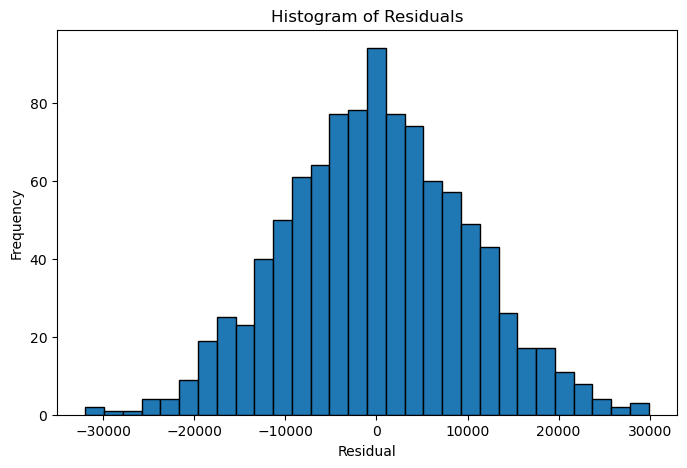

<Figure size 600x600 with 0 Axes>

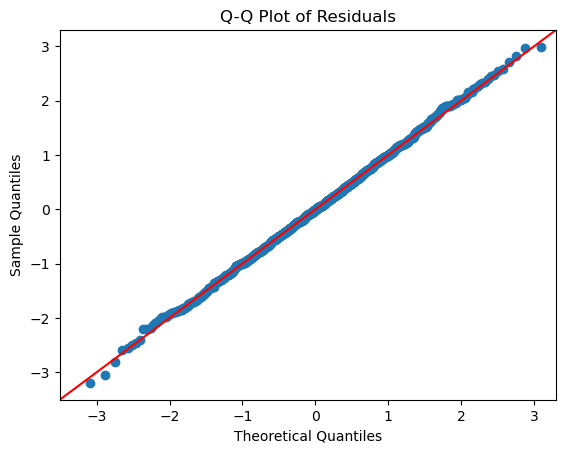

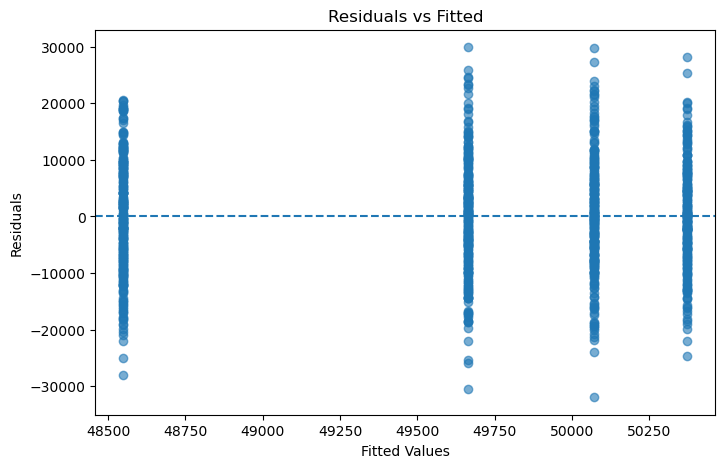

Shapiro-Wilk test statistic: 0.9982530706813116
Shapiro-Wilk p-value: 0.8993625420483238


In [41]:
#Residual analysis for one-way ANOVA

model = ols('Salary ~ C(Major)', data=df).fit()

residuals = model.resid
fitted = model.fittedvalues

#Histogram of residuals
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

#Q-Q plot
plt.figure(figsize=(6,6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

#Residuals vs fitted
plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

#Shapiro-Wilk test
stat, p = shapiro(residuals.sample(min(len(residuals), 500), random_state=1663))
print("Shapiro-Wilk test statistic:", stat)
print("Shapiro-Wilk p-value:", p)

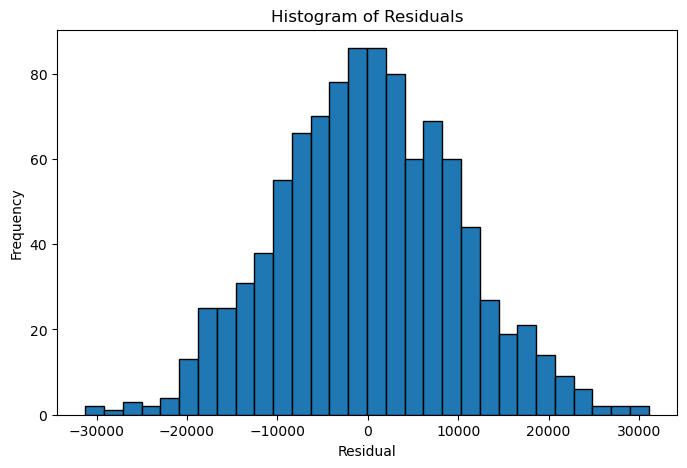

<Figure size 600x600 with 0 Axes>

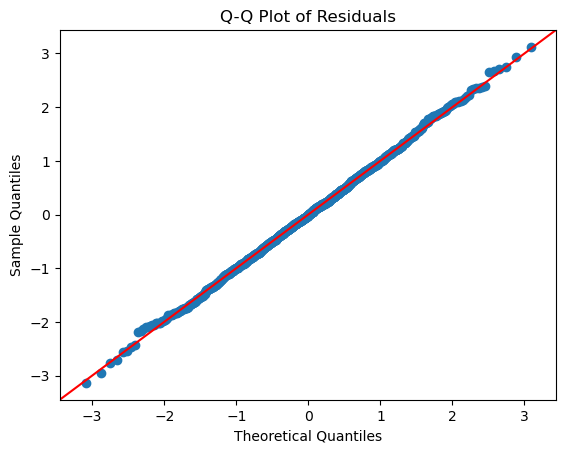

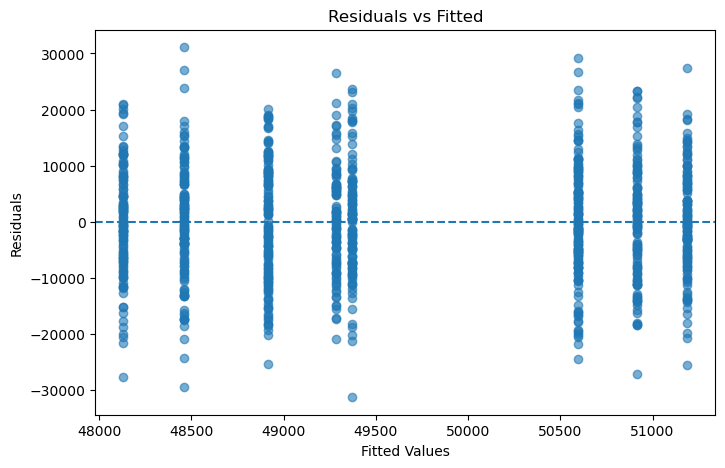

In [34]:
#Residual analysis for two-way ANOVA

model = ols('Salary ~ C(Major) * C(School_Type)', data=df).fit()

residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [36]:
#Welch's ANOVA for Unequal Variance 

from statsmodels.stats.oneway import anova_oneway

anova_oneway(
    data=df["Salary"],
    groups=df["Major"],
    use_var="unequal"
)

<class 'statsmodels.stats.base.HolderTuple'>
statistic = np.float64(1.597471803355275)
pvalue = np.float64(0.18895015336493814)
df = (3.0, np.float64(551.9421102559222))
df_num = 3.0
df_denom = np.float64(551.9421102559222)
nobs_t = np.float64(1000.0)
n_groups = 4
means = array([48549.42776333, 49664.35862912, 50070.23347282, 50372.76796279])
nobs = array([257., 253., 263., 227.])
vars_ = array([1.04130087e+08, 1.06058082e+08, 1.03292105e+08, 8.63929483e+07])
use_var = 'unequal'
welch_correction = True
tuple = (np.float64(1.597471803355275), np.float64(0.18895015336493814))

In [35]:
#Non-Parametric Kruskal-Wallis test

from scipy.stats import kruskal

groups = [group["Salary"].values for _, group in df.groupby("Major")]
stat, p = kruskal(*groups)
print("Kruskal-Wallis statistic:", stat)
print("p-value:", p)

Kruskal-Wallis statistic: 3.466187579214875
p-value: 0.32517402918287225


In [40]:
import pingouin as pg

#Unequal sample sizes and unequal variances
g1 = np.random.normal(loc=50, scale=5, size=120)   #big n, small variance
g2 = np.random.normal(loc=53, scale=25, size=25)   #small n, huge variance
g3 = np.random.normal(loc=56, scale=40, size=15)   #smaller n, even bigger variance

df_demo = pd.DataFrame({
    "Score": np.concatenate([g1, g2, g3]),
    "Group": (["A"] * len(g1)) + (["B"] * len(g2)) + (["C"] * len(g3))
})

print(df_demo.groupby("Group")["Score"].agg(["count", "mean", "std"]))
print()

groups = [g["Score"].values for _, g in df_demo.groupby("Group")]
lev_stat, lev_p = levene(*groups)
print("Levene test")
print("Statistic:", lev_stat)
print("p-value:", lev_p)
print()

#ANOVA
model = ols("Score ~ C(Group)", data=df_demo).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("Standard ANOVA")
print(anova_table)
print()

#Welch ANOVA via statsmodels
welch_result = anova_oneway(
    data=df_demo["Score"],
    groups=df_demo["Group"],
    use_var="unequal"
)
print("Welch ANOVA (statsmodels)")
print(welch_result)
print()

#Welch ANOVA via pingouin
#print("Welch ANOVA (pingouin)")
#print(pg.welch_anova(dv="Score", between="Group", data=df_demo))

pg.pairwise_gameshowell(dv='Score', between='Group', data=df_demo)

       count       mean        std
Group                             
A        120  50.244978   5.256912
B         25  56.219816  22.324012
C         15  70.828105  24.520333

Levene test
Statistic: 65.38667473257442
p-value: 2.2011662075066443e-21

Standard ANOVA
                sum_sq     df          F        PR(>F)
C(Group)   5935.743892    2.0  19.688241  2.347463e-08
Residual  23666.710013  157.0        NaN           NaN

Welch ANOVA (statsmodels)
statistic = 5.94001785474537
pvalue = 0.008037169482247782
df = (2.0, np.float64(23.948044191831045))
df_num = 2.0
df_denom = 23.948044191831045
nobs_t = 160.0
n_groups = 3
means = [50.2449785 56.219816  70.8281051]
nobs = [120.  25.  15.]
vars_ = [ 27.63512222 498.36150049 601.24674688]
use_var = unequal
welch_correction = True
tuple = (np.float64(5.94001785474537), np.float64(0.008037169482247782))



,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,A,B,50.244978,56.219816,-5.974838,4.490518,-1.330545,24.557062,0.392239,-0.575549
1,A,C,50.244978,70.828105,-20.583127,6.349284,-3.241803,14.161278,0.015102,-2.181583
2,B,C,56.219816,70.828105,-14.608289,7.747101,-1.885646,27.430271,0.161907,-0.618292


In [ ]:
#Repeated Measures 
from statsmodels.stats.anova import AnovaRM
df1 = pd.read_csv('../../datasets/repeated_anova.csv')
df1.head()

In [50]:
#Repeated Measures - 1 Way

from statsmodels.stats.anova import AnovaRM
df1 = pd.read_csv('../../datasets/anova_repeated_1.csv')
print(df1.head())
rm_anova = AnovaRM(data=df1, depvar="Score", subject="Subject", within=["Time"]).fit()
print(rm_anova)

   Subject  Time      Score
0        1   Pre  73.420656
1        1   Mid  81.564467
2        1  Post  90.065833
3        2   Pre  67.190225
4        2   Mid  79.443624
              Anova
     F Value Num DF  Den DF Pr > F
----------------------------------
Time 57.2189 2.0000 58.0000 0.0000



In [51]:
#Repeated Measures - 2 Way
df2 = pd.read_csv('../../datasets/anova_repeated_2.csv')
print(df2.head())
rm_anova_2way = AnovaRM(
    data=df2,
    depvar="Score",
    subject="Subject",
    within=["Time", "Condition"]
).fit()

print(rm_anova_2way)

   Subject  Time  Condition      Score
0        1   Pre    Control  52.565492
1        1   Pre  Treatment  57.923351
2        1  Post    Control  61.549374
3        1  Post  Treatment  64.277825
4        2   Pre    Control  53.332817
                   Anova
               F Value Num DF  Den DF Pr > F
--------------------------------------------
Time           91.3719 1.0000 23.0000 0.0000
Condition      88.4881 1.0000 23.0000 0.0000
Time:Condition 14.3268 1.0000 23.0000 0.0010

